<a href="https://colab.research.google.com/github/Shravanee-ExelR/Syntecxhub_project/blob/main/Syntecxhub_task4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
#Load Dataset
df=pd.read_csv('/content/Sales Dataset.csv')
df.head(100)

,Order ID,Amount,Profit,Quantity,Category,Sub-Category,PaymentMode,Order Date,CustomerName,State,City,Year-Month
0,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
1,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
2,B-26776,9726,1275,5,Electronics,Electronic Games,UPI,2021-07-25,Robert Stone,New York,Buffalo,2021-07
3,B-26776,4975,1330,14,Electronics,Printers,UPI,2023-06-27,David Padilla,Florida,Miami,2023-06
4,B-26776,4975,1330,14,Electronics,Printers,UPI,2024-12-27,Connor Morgan,Illinois,Chicago,2024-12
...,...,...,...,...,...,...,...,...,...,...,...,...
95,B-25142,5105,465,5,Electronics,Printers,UPI,2021-11-12,Marc Strickland,Florida,Orlando,2021-11
96,B-25326,5578,277,16,Furniture,Tables,COD,2021-08-17,Charlene Brown,Florida,Miami,2021-08
97,B-25326,5578,277,16,Furniture,Tables,COD,2022-05-16,Charles Smith,Ohio,Columbus,2022-05
98,B-26795,5224,1958,16,Furniture,Chairs,Credit Card,2023-07-16,Karen Townsend,Texas,Houston,2023-07


In [ ]:
df.columns

Index(['Order ID', 'Amount', 'Profit', 'Quantity', 'Category', 'Sub-Category',
       'PaymentMode', 'Order Date', 'CustomerName', 'State', 'City',
       'Year-Month'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1194 entries, 0 to 1193
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Order ID      1194 non-null   object
 1   Amount        1194 non-null   int64 
 2   Profit        1194 non-null   int64 
 3   Quantity      1194 non-null   int64 
 4   Category      1194 non-null   object
 5   Sub-Category  1194 non-null   object
 6   PaymentMode   1194 non-null   object
 7   Order Date    1194 non-null   object
 8   CustomerName  1194 non-null   object
 9   State         1194 non-null   object
 10  City          1194 non-null   object
 11  Year-Month    1194 non-null   object
dtypes: int64(3), object(9)
memory usage: 112.1+ KB


In [ ]:
df.describe()

,Amount,Profit,Quantity
count,1194.000000,1194.000000,1194.000000
mean,5178.089615,1348.992462,10.674204
std,2804.921955,1117.992573,5.777102
min,508.000000,50.000000,1.000000
25%,2799.000000,410.000000,6.000000
50%,5152.000000,1014.000000,11.000000
75%,7626.000000,2035.000000,16.000000
max,9992.000000,4930.000000,20.000000


In [ ]:
df.shape

(1194, 12)

In [ ]:
df.isnull().sum()

,0
Order ID,0
Amount,0
Profit,0
Quantity,0
Category,0
Sub-Category,0
PaymentMode,0
Order Date,0
CustomerName,0
State,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.dtypes

,0
Order ID,object
Amount,int64
Profit,int64
Quantity,int64
Category,object
Sub-Category,object
PaymentMode,object
Order Date,object
CustomerName,object
State,object


In [ ]:
#Overall Sales Trend
df['Order Date'].min()

Timestamp('2020-03-22 00:00:00')

In [ ]:
df['Order Date'].max()

Timestamp('2025-03-15 00:00:00')

In [ ]:
df['month_year']=df['Order Date'].apply(lambda x:x.strftime('%Y-%m'))

In [ ]:
df['month_year']

,month_year
0,2023-06
1,2024-12
2,2021-07
3,2023-06
4,2024-12
...,...
1189,2024-07
1190,2020-06
1191,2022-12
1192,2020-08


In [ ]:
#Creating New Columns(for analysis)
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Order Date']=pd.to_datetime(df['Order Date'])

In [ ]:
df['Year']=df['Order Date'].dt.year
df['Month']=df['Order Date'].dt.month

In [ ]:
#KPI Calculations
#Total Revenue
total_revenue=df['Amount'].sum()
print("Total Revenue:",total_revenue)

Total Revenue: 6182639


In [ ]:
#KPI Calculations
#Average Order Value
avg_order_value=df['Profit'].mean()
print("Average Order Value:",avg_order_value)

Average Order Value: 1348.9924623115578


In [ ]:
#Top Region
top_regions=df.groupby('Profit')['Quantity'].sum().sort_values(ascending=False)
print(top_regions)

Profit
177     121
158      96
1605     80
1849     76
936      72
       ... 
3043      1
2812      1
1270      1
829       1
4111      1
Name: Quantity, Length: 707, dtype: int64


In [ ]:
top_products=df.groupby('Quantity')['Amount'].sum().sort_values(ascending=False).head(10)
print(top_products)

Quantity
19    406539
14    379681
5     373858
15    351605
12    345503
13    344766
16    336585
18    324142
6     318767
1     312946
Name: Amount, dtype: int64


In [ ]:
#Top state
top_state=df.groupby('Profit')['Amount'].sum().sort_values(ascending=False)
print(top_state)

Profit
893     40820
1014    38732
936     36398
2444    35086
1686    32379
        ...  
197       706
238       702
300       611
189       531
83        526
Name: Amount, Length: 707, dtype: int64


In [ ]:
#Top state
top_state=df.groupby('State')['Amount'].sum().sort_values(ascending=False)
print(top_state)

State
New York      1130048
Florida       1091174
California    1086436
Texas         1011475
Illinois       978738
Ohio           884768
Name: Amount, dtype: int64


In [ ]:
#most profitable category and sub-category
category_subcategory_sales = df.groupby(['Category','Sub-Category'])['Amount'].sum().sort_values(ascending=False)
print(category_subcategory_sales)

Category         Sub-Category    
Office Supplies  Markers             627875
Furniture        Tables              625177
                 Sofas               568367
Electronics      Printers            566359
                 Electronic Games    565092
Office Supplies  Pens                552269
                 Paper               524755
Electronics      Phones              503055
Furniture        Chairs              431964
Electronics      Laptops             419950
Furniture        Bookcases           413165
Office Supplies  Binders             384611
Name: Amount, dtype: int64


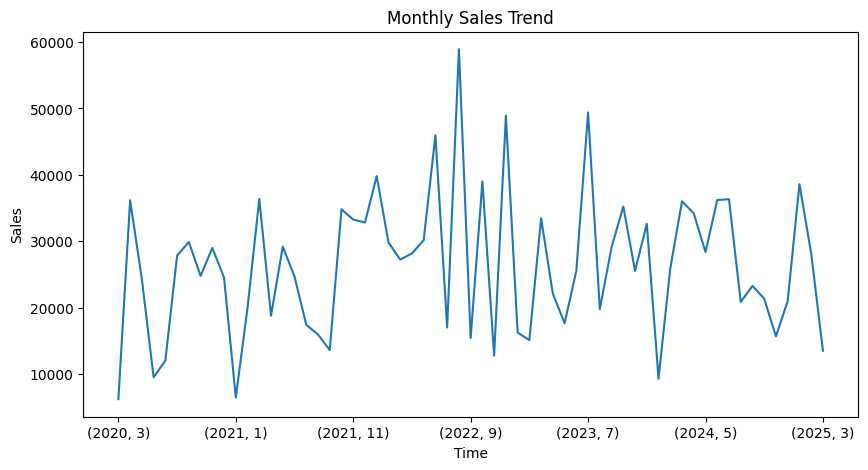

In [ ]:
#sales trend
monthly_sales=df.groupby(['Year','Month'])['Profit'].sum()
monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.show()

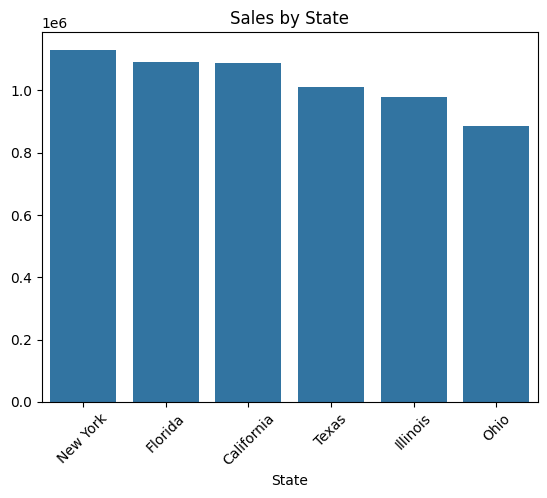

In [ ]:
sns.barplot(x=top_state.index,y=top_state.values)
plt.title("Sales by State")
plt.xticks(rotation=45)
plt.show()

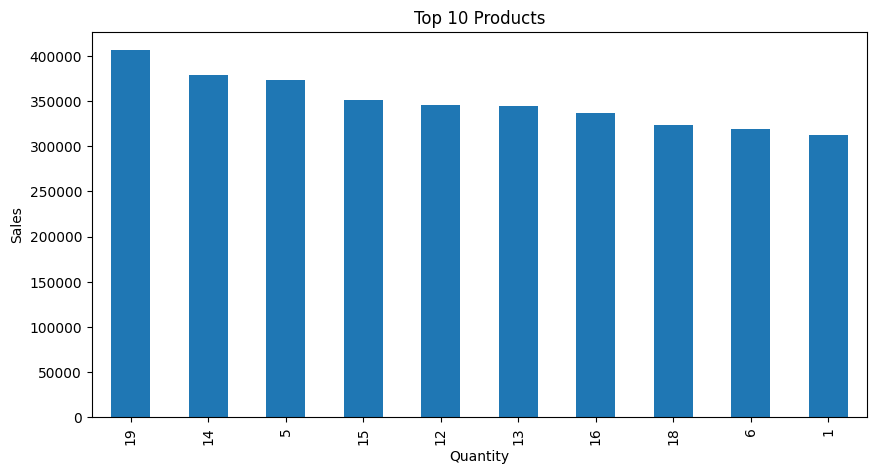

In [ ]:
#Top Products
top_products.plot(kind='bar',figsize=(10,5))
plt.title("Top 10 Products")
plt.ylabel("Sales")
plt.show()

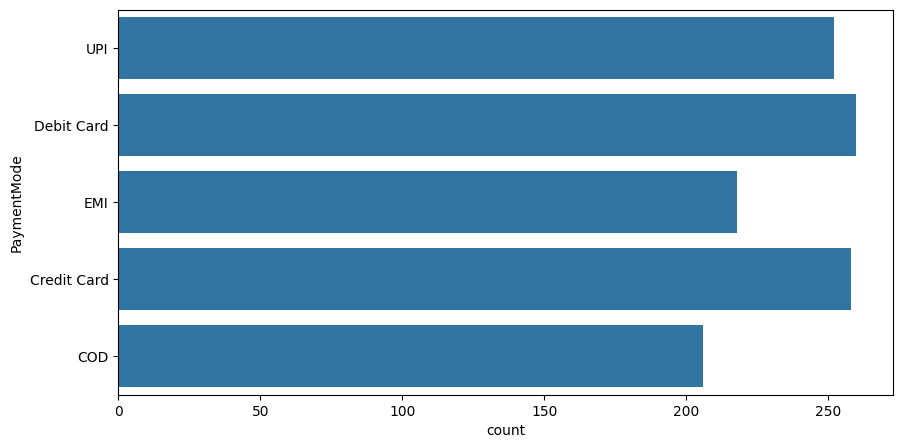

In [ ]:
#Plotting Payment Mode
plt.figure(figsize=(10,5))
sns.countplot(df['PaymentMode'])
plt.show()

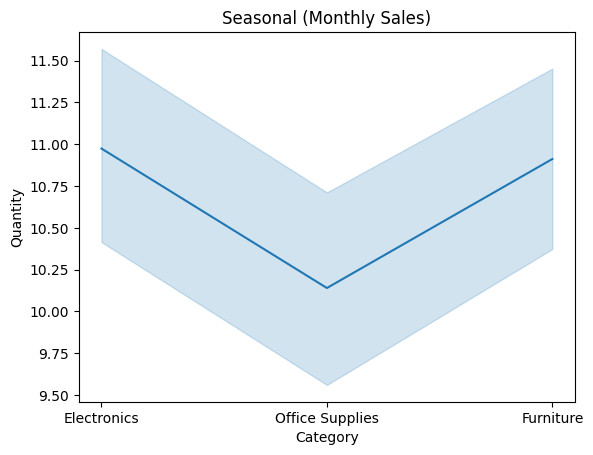

In [ ]:
#Seasonality Analysis
sns.lineplot(x='Category',y='Quantity',data=df)
plt.title("Seasonal (Monthly Sales)")
plt.show()

# **PROJECT SUMMARY**

**Sales Analysis Report**










In [3]:
from google.colab import files
uploaded=files.upload()

Saving SYN Task_4_Report.docx to SYN Task_4_Report (1).docx


In [4]:
import os
os.listdir()

['.config',
 'SYN Task_4_Report.docx',
 'SYN Task_4_Report (1).docx',
 'sample_data']

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
file_path='/content/SYN Task_4_Report.docx'

In [8]:
!pip install python-docx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 6.6 MB/s eta 0:00:00


In [9]:
from docx import Document
doc=Document('SYN Task_4_Report.docx')
for para in doc.paragraphs:
  print(para.text)

                                       SYNTECXHUB INTERNSHIP
                                                   Project 1: Sales Analysis   
                                                                   ( Project Summary)
 Sales Analysis Report
 KPIs:
Total Revenue: 6182639
Average Order Value: 1348.99
Top State: New York
 Insights:
Highest Sales came from West Region.
Technology Products performs best.
Sales peak during November-December.
Analysis Charts:
1. Sales By State






2. Monthly Sales Trend 


3. Seasonal Sales.




In [ ]:
#KPI for Summary report
total_revenue=df['Amount'].sum()
avg_order_value=df['Amount'].mean()
top_state=df.groupby('State')['Amount'].sum().idxmax()
print("Total Revenue:",total_revenue)
print("Average Order Value:",avg_order_value)
print("Top State:",top_state)

Total Revenue: 6182639
Average Order Value: 5178.089614740368
Top State: New York


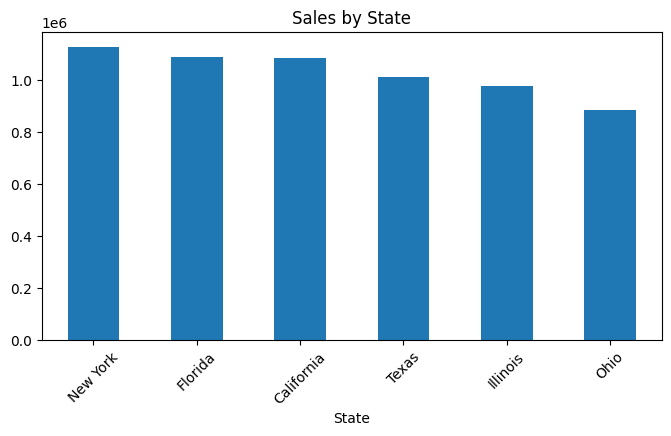

In [ ]:
#Adding Charts to Report

#1.Sales by state
top_state_data=df.groupby('State')['Amount'].sum().sort_values(ascending=False)
top_state_data.plot(kind='bar',figsize=(8,4))
plt.title("Sales by State")
plt.xticks(rotation=45)
plt.show()

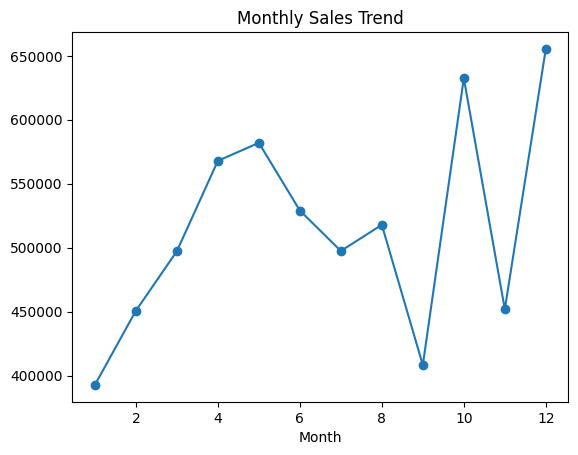

In [ ]:
#2.Monthly Sales Trend
df['Order Date']=pd.to_datetime(df['Order Date'])
df['Month']=df['Order Date'].dt.month
monthly_sales=df.groupby('Month')['Amount'].sum()
monthly_sales.plot(kind='line',marker='o')
plt.title("Monthly Sales Trend")
plt.show()


# Sales Analysis Report

`KPIs`


*   Total Revenue: 6182639
*   Average Order Value: 1348.99


*  Top State: New York

`Insights`


*   Highest Sales came from West Region.
*   Technology Products performs best.


*   Sales peak during November-December.







